In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("laptop_price.csv")
df.head()

,Company,TypeName,Ram,OS,Weight,Screen,ScreenW,ScreenH,Touchscreen,IPSpanel,RetinaDisplay,CPU_company,CPU_freq,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,Price_PKR
0,Apple,Ultrabook,8,macOS,1.37,Standard,2560,1600,No,Yes,Yes,Intel,2.3,0,SSD,No,Intel,423342.0
1,Apple,Ultrabook,8,macOS,1.34,Standard,1440,900,No,No,No,Intel,1.8,0,Flash Storage,No,Intel,284065.0
2,HP,Notebook,8,No OS,1.86,Full HD,1920,1080,No,No,No,Intel,2.5,0,SSD,No,Intel,181700.0
3,Apple,Ultrabook,16,macOS,1.83,Standard,2880,1800,No,Yes,Yes,Intel,2.7,0,SSD,No,AMD,801834.0
4,Apple,Ultrabook,8,macOS,1.37,Standard,2560,1600,No,Yes,Yes,Intel,3.1,0,SSD,No,Intel,569938.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   TypeName              1275 non-null   object 
 2   Ram                   1275 non-null   int64  
 3   OS                    1275 non-null   object 
 4   Weight                1275 non-null   float64
 5   Screen                1275 non-null   object 
 6   ScreenW               1275 non-null   int64  
 7   ScreenH               1275 non-null   int64  
 8   Touchscreen           1275 non-null   object 
 9   IPSpanel              1275 non-null   object 
 10  RetinaDisplay         1275 non-null   object 
 11  CPU_company           1275 non-null   object 
 12  CPU_freq              1275 non-null   float64
 13  SecondaryStorage      1275 non-null   int64  
 14  PrimaryStorageType    1275 non-null   object 
 15  SecondaryStorageType 

In [4]:
df.describe()

,Ram,Weight,ScreenW,ScreenH,CPU_freq,SecondaryStorage,Price_PKR
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1.275000e+03
mean,8.440784,2.040525,1900.043922,1073.904314,2.302980,176.069020,3.586502e+05
std,5.097809,0.669196,493.346186,283.883940,0.503846,415.960655,2.214378e+05
min,2.000000,0.690000,1366.000000,768.000000,0.900000,0.000000,5.498400e+04
25%,4.000000,1.500000,1920.000000,1080.000000,2.000000,0.000000,1.924440e+05
50%,8.000000,2.040000,1920.000000,1080.000000,2.500000,0.000000,3.125240e+05
75%,8.000000,2.310000,1920.000000,1080.000000,2.700000,0.000000,4.728940e+05
max,64.000000,4.700000,3840.000000,2160.000000,3.600000,2048.000000,1.927284e+06


## Data Cleaning

**1) Missing Values Check**

In [5]:
df.isnull().sum()

Company                 0
TypeName                0
Ram                     0
OS                      0
Weight                  0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
Price_PKR               0
dtype: int64

**2) Duplicate Rows Check**

In [6]:
df.duplicated().sum()

np.int64(1)

**Dropping duplicated**

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# df.columns
df.columns.tolist()

['Company',
 'TypeName',
 'Ram',
 'OS',
 'Weight',
 'Screen',
 'ScreenW',
 'ScreenH',
 'Touchscreen',
 'IPSpanel',
 'RetinaDisplay',
 'CPU_company',
 'CPU_freq',
 'SecondaryStorage',
 'PrimaryStorageType',
 'SecondaryStorageType',
 'GPU_company',
 'Price_PKR']

In [10]:
df.dtypes

Company                  object
TypeName                 object
Ram                       int64
OS                       object
Weight                  float64
Screen                   object
ScreenW                   int64
ScreenH                   int64
Touchscreen              object
IPSpanel                 object
RetinaDisplay            object
CPU_company              object
CPU_freq                float64
SecondaryStorage          int64
PrimaryStorageType       object
SecondaryStorageType     object
GPU_company              object
Price_PKR               float64
dtype: object

## Encoding

In [11]:
df = pd.get_dummies(
    df,
    columns=[
        'Company',
        'TypeName',
        'OS',
        'Screen',
        'Touchscreen',
        'IPSpanel',
        'RetinaDisplay',
        'CPU_company',
        'PrimaryStorageType',
        'SecondaryStorageType',
        'GPU_company'
    ],
    dtype=int
)

In [12]:
df.head()

,Ram,Weight,ScreenW,ScreenH,CPU_freq,SecondaryStorage,Price_PKR,Company_Acer,Company_Apple,Company_Asus,...,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,SecondaryStorageType_HDD,SecondaryStorageType_Hybrid,SecondaryStorageType_No,SecondaryStorageType_SSD,GPU_company_AMD,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia
0,8,1.37,2560,1600,2.3,0,423342.0,0,1,0,...,0,1,0,0,1,0,0,0,1,0
1,8,1.34,1440,900,1.8,0,284065.0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,8,1.86,1920,1080,2.5,0,181700.0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
3,16,1.83,2880,1800,2.7,0,801834.0,0,1,0,...,0,1,0,0,1,0,1,0,0,0
4,8,1.37,2560,1600,3.1,0,569938.0,0,1,0,...,0,1,0,0,1,0,0,0,1,0


In [13]:
df.columns

Index(['Ram', 'Weight', 'ScreenW', 'ScreenH', 'CPU_freq', 'SecondaryStorage',
       'Price_PKR', 'Company_Acer', 'Company_Apple', 'Company_Asus',
       'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google',
       'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo',
       'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'OS_Android', 'OS_Chrome OS', 'OS_Linux', 'OS_Mac OS X', 'OS_No OS',
       'OS_Windows 10', 'OS_Windows 10 S', 'OS_Windows 7', 'OS_macOS',
       'Screen_4K Ultra HD', 'Screen_Full HD', 'Screen_Quad HD+',
       'Screen_Standard', 'Touchscreen_No', 'Touchscreen_Yes', 'IPSpanel_No',
       'IPSpanel_Yes', 'RetinaDisplay_No', 'RetinaDisplay_Yes',
       'CPU_company_AMD', 'CPU_company_I

In [14]:
X = df.drop('Price_PKR', axis=1)
X

,Ram,Weight,ScreenW,ScreenH,CPU_freq,SecondaryStorage,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,...,PrimaryStorageType_Hybrid,PrimaryStorageType_SSD,SecondaryStorageType_HDD,SecondaryStorageType_Hybrid,SecondaryStorageType_No,SecondaryStorageType_SSD,GPU_company_AMD,GPU_company_ARM,GPU_company_Intel,GPU_company_Nvidia
0,8,1.37,2560,1600,2.3,0,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
1,8,1.34,1440,900,1.8,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
2,8,1.86,1920,1080,2.5,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
3,16,1.83,2880,1800,2.7,0,0,1,0,0,...,0,1,0,0,1,0,1,0,0,0
4,8,1.37,2560,1600,3.1,0,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,4,2.20,1366,768,2.5,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
1270,4,1.80,1920,1080,2.5,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1271,16,1.30,3200,1800,2.5,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1272,2,1.50,1366,768,1.6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [15]:
y = df['Price_PKR']
y

0       423342.0
1       284065.0
2       181700.0
3       801834.0
4       569938.0
          ...   
1269    227621.0
1270    201608.0
1271    473684.0
1272     72364.0
1273    241424.0
Name: Price_PKR, Length: 1274, dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=2)

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
lr=LinearRegression()

In [19]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
lr.predict(X_test)

array([ 176180.26171329,  255689.5421863 ,   71496.88950287,
        717588.24814703,   86453.33865298,  353058.64644224,
        602926.3580964 ,  376506.67947653,  289393.07971349,
         -2506.54238497,  374539.09612111,  511169.74544051,
        436778.30134632,  292762.96318542,  136691.56153861,
        509804.8452034 ,  364496.2563702 ,   71496.88950287,
         71439.82395197,  260555.79431859,  158709.49496717,
        271998.57396661,  421064.63966313,  176180.26171329,
        405634.13772652,  453362.24148823,  251358.75225292,
        436778.30134632,  634174.81598193,  336885.07517209,
        257317.29548847,  230250.8449252 ,  228467.69662667,
        457136.7611538 ,  335011.41491073,  319533.51522727,
        128719.93371174,  257723.34972064,  457798.64507226,
        335544.10087529,  527588.00208975,  214400.75812848,
        242622.68558643,  368829.60815312,  293673.80273847,
        107911.21778304,  229922.76507259,   71044.72627083,
        277126.73998399,

In [21]:
y_pred=lr.predict(X_test)

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [23]:
rtwo_score= r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print(rtwo_score,mae,mse)

0.7821722172512091 75756.56291824044 10192562329.437809


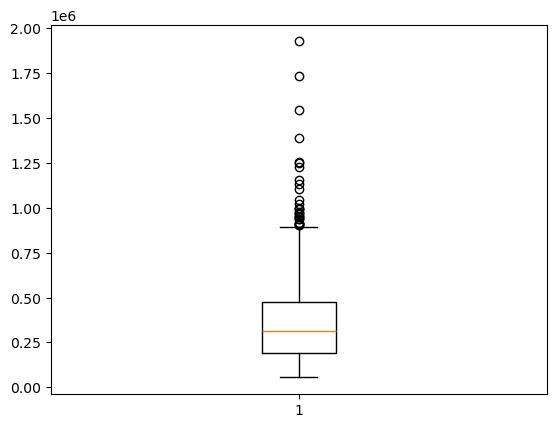

In [24]:
import matplotlib.pyplot as plt

plt.boxplot(df["Price_PKR"])
plt.show()

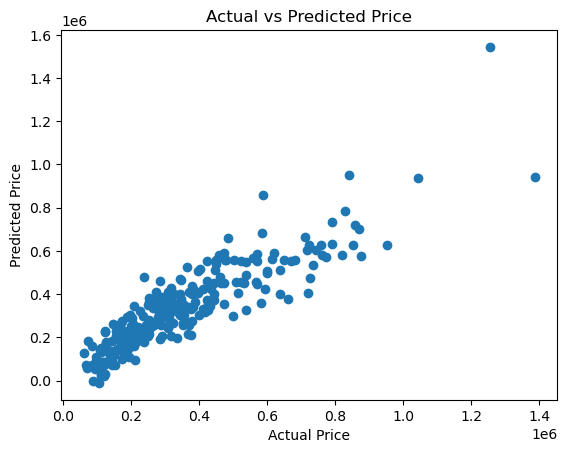

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()